In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from operator import itemgetter
from sklearn.neighbors import NearestNeighbors, KDTree
import time
import imageio
import os

In [2]:
df = pd.read_csv('./iris.csv')
cols = df.columns[:-1]

In [3]:
# sns.pairplot(data=df, hue='variety')

In [4]:
X = df.iloc[:, :-1]

### **OPTIMAL VALUE FOR EPSILON**

In [5]:
# https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc
# http://www.sefidian.com/2020/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/
neight = NearestNeighbors(n_neighbors=2)
nbrs = neight.fit(X)

distances, indices = nbrs.kneighbors(X)

In [6]:
distances = np.sort(distances, axis=0)
d = distances[:,1]

In [7]:
eps_op = -1
for i in range(1, len(d)):
    rate = d[i] - d[i-1]
    if  rate > eps_op:
        eps_op = rate
        x = i
eps_op

0.10239139080127757

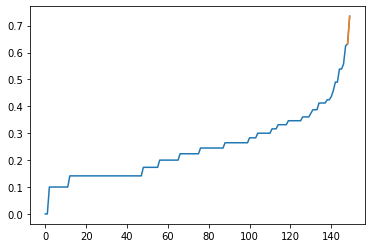

In [8]:
plt.clf()
plt.plot(d)     # linestyle="", marker='o', alpha=0.8, markersize=2
plt.plot([x-1, x], [d[x-1], d[x]])

In [9]:
print(f'median: {np.median(d)}')
print(f'mean: {np.mean(d)}')
# eps_op = np.mean([np.median(d), eps_op])
eps_op = np.mean(d)

median: 0.22360679774997935
mean: 0.24710674026810603


## **DBSCAN**

In [10]:
colors = ['gray', 'orange', 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w']
t1 = ('petal.width', 'petal.length')
t2 = ('petal.length', 'sepal.width')
t3 = ('sepal.length', 'petal.width')

UNDEFINED = 0
NOISE = 1

IMG_PATH = './img/'

In [11]:
class DBScan():
    def __init__(self, data, eps, treshold, m='euclidean'):
        self.data = data        # .sample(frac=1)
        self.KDT = KDTree(data.to_numpy(), metric=m)
        self.e = eps
        self.t = treshold

        self.label = [UNDEFINED for _ in range(len(data))]
    
    def region_query(self, p):
        N = self.KDT.query_radius([p], r=self.e)[0]                 # print(f'First N: {N}')
        N = [n for n in N if self.label[n] in [UNDEFINED, NOISE] ]  # print(f'Filtered N: {N}')
        return N

    def dbs(self):
        c = 1
        ii = 0
        for i in range(len(self.data)):
            if self.label[i] != UNDEFINED:
                continue
            
            p = d.iloc[i].to_numpy()
            N = self.region_query(p)
            
            if len(N) < self.t:
                self.label[i] = NOISE
                continue
            c += 1
            self.label[i] = c
            # self.save_plot(t1, ii)
            # ii += 1

            # S <- N \ {p}
            S = np.sort(np.delete(N, np.where(N==i)))

            j = 0
            lS = len(S)
            while j < lS:
                # foreach q in S do
                idx = S[j]
                q = d.iloc[idx].to_numpy()
                
                if self.label[idx] == NOISE:
                    self.label[idx] = c
                    # self.save_plot(t1, ii)
                    # ii += 1
                if (self.label[idx] != UNDEFINED):
                    j += 1
                    continue
                
                N_ = self.region_query(q)
                N_ = np.array([nn for nn in N_ if nn not in S])
                
                # label(q) <- c
                self.label[idx] = c
                # self.save_plot(t1, ii)
                # ii += 1
            
                # if |N| < minPts then continue
                if len(N_) < self.t:
                    j += 1
                    continue
                
                # S <- S U N
                S = np.concatenate((S, N_), axis=None).astype(int)
                lS = len(S)
                j += 1
                
            # self.save_plot(t1, ii)
            # ii += 1
        # self.build_gif(ii)
            
    
    def execute(self):
        self.dbs()
        
    def save_plot(self, xy, it):
        x, y = xy
        plt.clf()
        label_idx = pd.DataFrame(self.label, columns=['label'])
        for ker in np.unique(self.label):
            idx = label_idx[label_idx['label']==ker].index
            group = self.data.iloc[idx]
            plt.scatter(
                group[x], group[y], 
                c=colors[ker], alpha=.8, label=ker
                )
        plt.legend()
        # plt.savefig(f'{IMG_PATH + str(it)}.png')
        plt.show()

    # https://towardsdatascience.com/basics-of-gifs-with-pythons-matplotlib-54dd544b6f30
    def build_gif(self, n_images):        
        N_FRAMES = 2
        with imageio.get_writer(f'{IMG_PATH}DBScan.gif', mode='I') as writer:
            for _ in range(n_images):
                for f in range(N_FRAMES):
                    filename = f'{IMG_PATH + str(_)}.png'
                    image = imageio.imread(filename)
                    writer.append_data(image)

        for _ in range(n_images):
            os.remove(f'{IMG_PATH + str(_)}.png')


In [12]:
data = df.copy()
d = data.iloc[:,:-1]
r, dim = d.shape

In [13]:
t = dim
print(eps_op, t)

0.24710674026810603 4


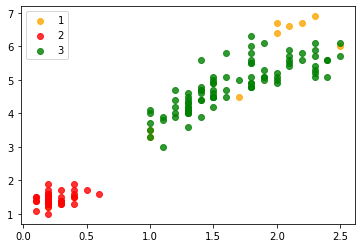

In [14]:
dbs = DBScan(data=d, eps=0.8, treshold=dim)
dbs.execute()
dbs.save_plot(t1, 0)

In [15]:
# https://github.com/scrunts23/CS-Data-Science-Build-Week-1/blob/master/model/dbscan.py
# https://scrunts23.medium.com/dbscan-algorithm-from-scratch-in-python-475b82e0571c
# http://primo.ai/index.php?title=Density-Based_Spatial_Clustering_of_Applications_with_Noise_(DBSCAN)